# Chess Self-Analysis: an analysis of my own chess

**Player:** [chefbadr](https://www.chess.com/member/Chefbadr) &middot; **Data source:** [Chess.com Published-Data API](https://www.chess.com/news/view/published-data-api) (free, public, no auth required)

This notebook is written as a walkthrough, not just a results dump — each section explains *what* we're
computing and *why*, the way you'd explain it to someone a year or two into a data science degree who
knows pandas but hasn't seen this particular API before.

**Roadmap:**

1. Load the raw data the download script pulled from Chess.com
2. Turn nested JSON + embedded PGN text into one tidy row-per-game DataFrame
3. Overview: how much chess have I played, and in what formats?
4. Rating progression over time, per time control
5. Win rate by colour
6. Win rate by opening
7. Performance by time of day and day of week
8. Performance vs. opponent rating difference
9. Instinct-player habits: the openings I fall into without knowing their names
10. Castling habits
11. Average game length, and how my games actually end
12. Which recurring patterns in my play win the most — and which lose the most
13. Headline stats (the numbers that end up in the README)
14. **Engine analysis (v2):** Stockfish-measured move quality — blunder rate by opening, phase, and time
    of day, plus the worst individual moves in the sample

> If you're re-running this: execute `scripts/download_games.py` first so `data/processed/games.json`
> exists locally. The raw+processed data is committed to this repo already, so you can also just run
> the notebook as-is against what's checked in.
>
> Section 14 additionally needs `data/processed/engine_analysis.csv`, produced by running
> `scripts/setup_engine.py` (once, to fetch Stockfish) and then `scripts/analyze_blunders.py` (which is
> slow — see that section for why). That output is also committed, so section 14 runs as-is too; you
> only need those scripts if you want to widen the sample or re-run on your own games.

## 0. Setup

Standard imports, plus a small amount of `matplotlib` styling so every chart in the notebook shares
one visual language instead of matplotlib's default colours. We fix a **categorical palette in a fixed
order** (so "White" and "rapid" always get the same colour no matter what else is on the chart) and a
separate **status palette** for win/draw/loss, since outcome is a state, not an arbitrary category.

In [1]:
import io
import json
import re
import warnings
from collections import Counter
from datetime import datetime, timezone

import chess.pgn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# --- chart styling (see the dataviz palette this project follows) ----------
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#008300", "#e34948"]
STATUS = {"win": "#0ca30c", "draw": "#fab219", "loss": "#d03b3b"}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_SECONDARY,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 11,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

ME = "chefbadr"
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## 1. Loading the raw data

`scripts/download_games.py` already did the API work: it called Chess.com's `/pub/player/{username}/games/archives`
endpoint to get one URL per calendar month the player was active, downloaded each month's JSON, and
stitched every game into `data/processed/games.json`.

Each element of that list is one game record straight from Chess.com. The important fields are:

- `pgn` — the full move text **plus PGN headers** (opening classification, ratings, timestamps, how the
  game ended) all packed into one string
- `white` / `black` — dicts with `username`, `rating`, and `result` (Chess.com's own result *code*,
  e.g. `"win"`, `"checkmated"`, `"resigned"`, `"timeout"`, `"agreed"` for a draw, etc.)
- `time_class` — `bullet` / `blitz` / `rapid` / `daily`
- `rules` — almost always `"chess"`; a handful of games are variants like `oddschess`, which we'll drop
  since concepts like "opening" and "castling" don't map cleanly onto them

Let's load it and look at one record.

In [2]:
with open(PROJECT_ROOT / "data" / "processed" / "games.json", encoding="utf-8") as f:
    raw_games = json.load(f)

print(f"{len(raw_games)} raw game records loaded")
print("rules breakdown:", Counter(g.get("rules") for g in raw_games))

raw_games[100]

1491 raw game records loaded
rules breakdown: Counter({'chess': 1488, 'oddschess': 3})


{'url': 'https://www.chess.com/game/live/67474366137',
 'pgn': '[Event "Live Chess"]\n[Site "Chess.com"]\n[Date "2023.01.14"]\n[Round "-"]\n[White "Roblopa"]\n[Black "Chefbadr"]\n[Result "0-1"]\n[CurrentPosition "rn2k2r/pq3p1p/7p/4b3/6b1/3P1N2/PPP2PPP/RN1Q2K1 w kq -"]\n[Timezone "UTC"]\n[ECO "C40"]\n[ECOUrl "https://www.chess.com/openings/Kings-Pawn-Opening-Kings-Knight-Gunderam-Defense-3.Bc4"]\n[UTCDate "2023.01.14"]\n[UTCTime "22:29:42"]\n[WhiteElo "748"]\n[BlackElo "698"]\n[TimeControl "600"]\n[Termination "Chefbadr won by resignation"]\n[StartTime "22:29:42"]\n[EndDate "2023.01.14"]\n[EndTime "22:31:46"]\n[Link "https://www.chess.com/game/live/67474366137"]\n\n1. e4 {[%clk 0:09:57.8]} 1... e5 {[%clk 0:09:57.7]} 2. Nf3 {[%clk 0:09:56.4]} 2... Qe7 {[%clk 0:09:50.1]} 3. Bc4 {[%clk 0:09:48.9]} 3... Nh6 {[%clk 0:09:43.8]} 4. d3 {[%clk 0:09:46.2]} 4... c6 {[%clk 0:09:33.8]} 5. Bxh6 {[%clk 0:09:40.8]} 5... gxh6 {[%clk 0:09:32.2]} 6. O-O {[%clk 0:09:38.9]} 6... d5 {[%clk 0:09:30]} 7. exd5 

## 2. From raw JSON to a tidy DataFrame

This is the heart of the ETL step. A few things are worth calling out because they're specific to this
dataset rather than general pandas technique:

**Working out who won and how.** Chess.com doesn't give you a single "how did this game end" field.
Instead *both* players get a `result` code, and you have to reason about the *pair*. If White's code is
`"win"`, Black's code (`"checkmated"`, `"resigned"`, `"timeout"`, `"abandoned"`) tells you *how*. If the
codes match (`"stalemate"`, `"repetition"`, `"agreed"`, `"insufficient"`, `"timevsinsufficient"`,
`"50move"`), it's a draw and the shared code tells you why. I checked this empirically against all 1,488
games below before trusting it — every pair that shows up in the data is one of these two shapes.

**Getting the opening name for free.** Chess.com already classifies every game's opening and encodes the
name into the `ECOUrl`, e.g.
`.../openings/Kings-Pawn-Opening-Kings-Knight-Gunderam-Defense-3.Bc4`. Since I don't know opening theory
myself, this is exactly what I want: I don't have to hand-label anything, I just turn the URL slug back
into readable text. I keep two versions — the **exact** name (useful for "what specific line do I keep
landing in") and a coarser **family** name with the trailing move numbers stripped (useful for "what
broad opening am I actually playing").

**Getting move-level detail.** Ratings, results and openings are all sitting in the JSON/PGN headers
already, but things like *my first move*, *whether and when I castled*, and *game length in moves* require
actually replaying the game. That's what `python-chess` is for: `chess.pgn.read_game` parses the PGN text
into a `Game` object, and walking `game.mainline_moves()` against a `Board` lets us ask, move by move,
what happened and whose move it was.

In [3]:
DECISIVE_REASON = {
    "checkmated": "Checkmate",
    "resigned": "Resignation",
    "timeout": "Timeout",
    "abandoned": "Abandoned",
}
DRAW_REASON = {
    "stalemate": "Stalemate",
    "repetition": "Repetition",
    "agreed": "Agreed draw",
    "insufficient": "Insufficient material",
    "timevsinsufficient": "Time vs insufficient material",
    "50move": "50-move rule",
}

def classify_termination(white_result: str, black_result: str):
    # Return (winner_color_or_'draw', human-readable reason).
    if white_result == black_result:
        return "draw", DRAW_REASON.get(white_result, white_result)
    reason_code = white_result if white_result != "win" else black_result
    winner = "white" if white_result == "win" else "black"
    return winner, DECISIVE_REASON.get(reason_code, reason_code)


def opening_name_from_url(url: str) -> str:
    if not url:
        return "Unclassified"
    slug = url.rstrip("/").split("/")[-1]
    name = slug.replace("-", " ")
    return "Unclassified" if name == "Undefined" else name


def opening_family(name: str) -> str:
    # Strip trailing move notation ('3...b5 4.Bc4') to get the coarse opening family.
    tokens, out = name.split(" "), []
    for tok in tokens:
        if re.match(r"^\d", tok):
            break
        out.append(tok)
    fam = " ".join(out).strip()
    return fam if fam else name


def parse_game(g: dict) -> dict | None:
    if g.get("rules") != "chess" or not g.get("pgn"):
        return None
    game = chess.pgn.read_game(io.StringIO(g["pgn"]))
    if game is None:
        return None
    headers = game.headers

    my_color = "white" if g["white"]["username"].lower() == ME else "black"
    opp_color = "black" if my_color == "white" else "white"

    winner_color, reason = classify_termination(g["white"]["result"], g["black"]["result"])
    outcome = "draw" if winner_color == "draw" else ("win" if winner_color == my_color else "loss")

    try:
        dt_utc = datetime.strptime(
            f"{headers.get('UTCDate')} {headers.get('UTCTime')}", "%Y.%m.%d %H:%M:%S"
        ).replace(tzinfo=timezone.utc)
    except (ValueError, TypeError):
        dt_utc = datetime.fromtimestamp(g["end_time"], tz=timezone.utc)

    # Replay the game move-by-move to get SAN text and whose move each one was.
    board = game.board()
    sans = []
    for move in game.mainline_moves():
        is_white_move = board.turn  # True: White to move -> this move belongs to White
        sans.append((board.san(move), is_white_move))
        board.push(move)

    my_is_white = my_color == "white"
    my_sans = [s for s, is_white in sans if is_white == my_is_white]
    first_move_mine = my_sans[0] if my_sans else None

    castle_side = castle_move_number = None
    for i, (san, is_white) in enumerate(sans):
        if is_white == my_is_white and san in ("O-O", "O-O-O"):
            castle_side = "kingside" if san == "O-O" else "queenside"
            castle_move_number = i // 2 + 1
            break

    opening_url = g.get("eco")
    opening_name = opening_name_from_url(opening_url)

    return {
        "uuid": g.get("uuid"),
        "url": g.get("url"),
        "datetime_utc": dt_utc,
        "time_class": g.get("time_class"),
        "time_control": g.get("time_control"),
        "rated": g.get("rated"),
        "my_color": my_color,
        "opponent": g[opp_color]["username"],
        "my_rating": g[my_color]["rating"],
        "opponent_rating": g[opp_color]["rating"],
        "rating_diff": g[my_color]["rating"] - g[opp_color]["rating"],
        "outcome": outcome,
        "termination_reason": reason,
        "eco_code": headers.get("ECO"),
        "opening_name": opening_name,
        "opening_family": opening_family(opening_name),
        "num_plies": len(sans),
        "num_full_moves": (len(sans) + 1) // 2,
        "first_move_mine": first_move_mine,
        "castled": castle_side is not None,
        "castle_side": castle_side,
        "castle_move_number": castle_move_number,
    }


rows = [r for g in raw_games if (r := parse_game(g)) is not None]
df = pd.DataFrame(rows)

# A local time-of-day view: Chess.com timestamps are UTC, chefbadr's profile is set to Yemen (UTC+3).
df["datetime_local"] = df["datetime_utc"] + pd.Timedelta(hours=3)
df["day_of_week"] = df["datetime_local"].dt.day_name()
df["hour_of_day"] = df["datetime_local"].dt.hour

DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=DOW_ORDER, ordered=True)

print(f"{len(raw_games) - len(df)} non-standard-chess games dropped (variants like odds chess)")
print(f"{len(df)} games in the tidy dataset")

df.to_csv(PROJECT_ROOT / "data" / "processed" / "games_tidy.csv", index=False)
df.head(3)

3 non-standard-chess games dropped (variants like odds chess)
1488 games in the tidy dataset


,uuid,url,datetime_utc,time_class,time_control,rated,my_color,opponent,my_rating,opponent_rating,rating_diff,outcome,termination_reason,eco_code,opening_name,opening_family,num_plies,num_full_moves,first_move_mine,castled,castle_side,castle_move_number,datetime_local,day_of_week,hour_of_day
0,fc24bc47-6bd7-11ed-a6e4-78ac4409ff3c,https://www.chess.com/game/live/63019821639,2022-11-24 09:12:13+00:00,rapid,600,True,white,heomal,294,369,-75,loss,Checkmate,C20,Kings Pawn Opening 1...e5,Kings Pawn Opening,122,61,e4,True,kingside,16.0,2022-11-24 12:12:13+00:00,Thursday,12
1,abb2b92a-6bdb-11ed-a6e4-78ac4409ff3c,https://www.chess.com/game/live/63021601043,2022-11-24 09:38:04+00:00,rapid,600,True,black,heomal,170,376,-206,loss,Abandoned,C40,Kings Pawn Opening Kings Knight Variation,Kings Pawn Opening Kings Knight Variation,15,8,e5,False,NaN,NaN,2022-11-24 12:38:04+00:00,Thursday,12
2,9857521c-6bdc-11ed-a6e4-78ac4409ff3c,https://www.chess.com/game/live/63022161203,2022-11-24 09:45:33+00:00,rapid,600,True,white,heomal,351,364,-13,win,Checkmate,A40,Queens Pawn Opening Mikenas Defense,Queens Pawn Opening Mikenas Defense,87,44,d4,True,kingside,33.0,2022-11-24 12:45:33+00:00,Thursday,12


## 3. Overview: how much chess have I actually played?

Before drilling into behaviour, a sanity-check on the shape of the dataset: how many games, over what
time span, and in what formats. This also answers "what are my most common time controls" directly.

1488 games from 2022-11-24 to 2026-08-07 (1351 days)
93% rated


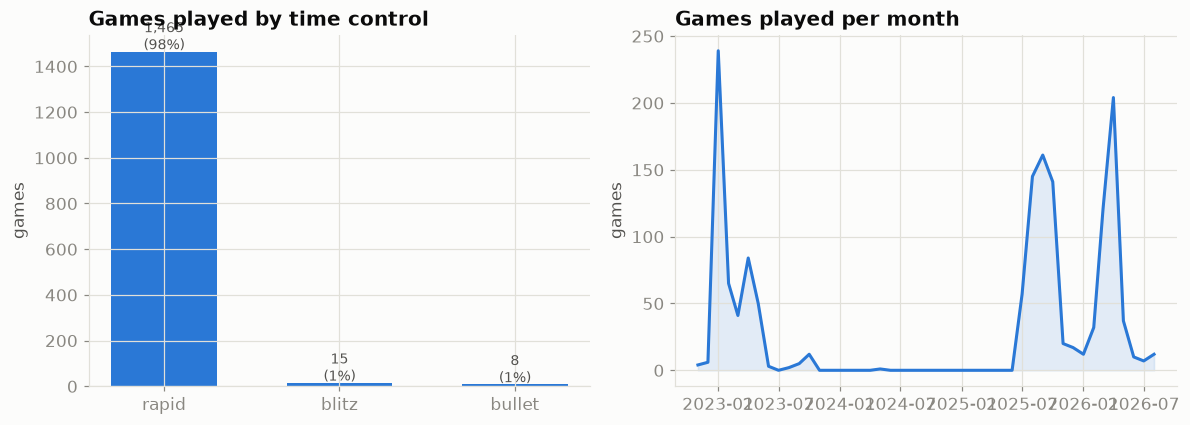

In [4]:
span_days = (df["datetime_utc"].max() - df["datetime_utc"].min()).days
print(f"{len(df)} games from {df['datetime_utc'].min().date()} to {df['datetime_utc'].max().date()} ({span_days} days)")
print(f"{df['rated'].mean():.0%} rated")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tc_counts = df["time_class"].value_counts()
axes[0].bar(tc_counts.index, tc_counts.values, color=CATEGORICAL[0], width=0.6)
axes[0].set_title("Games played by time control")
axes[0].set_ylabel("games")
for i, v in enumerate(tc_counts.values):
    axes[0].text(i, v + 10, f"{v:,}\n({v/len(df):.0%})", ha="center", color=INK_SECONDARY, fontsize=9)

games_per_month = df.set_index("datetime_utc").resample("MS").size()
axes[1].plot(games_per_month.index, games_per_month.values, color=CATEGORICAL[0], linewidth=2)
axes[1].fill_between(games_per_month.index, games_per_month.values, color=CATEGORICAL[0], alpha=0.12)
axes[1].set_title("Games played per month")
axes[1].set_ylabel("games")

plt.tight_layout()
plt.show()

## 4. Rating progression over time, per time control

Chess.com stamps every game with each player's rating **at the time that game was played**, so
`my_rating` already gives us a rating history for free — no separate stats-endpoint call needed. Each
time class (bullet/blitz/rapid/daily) has its own independent rating in Chess.com's system, so we plot
them as separate lines rather than one blended line.

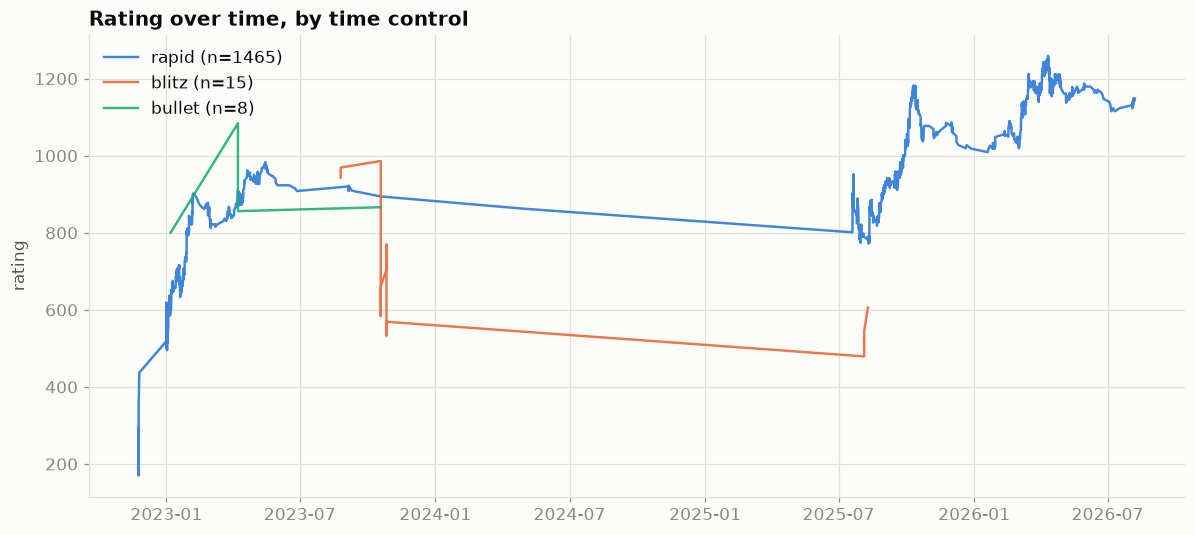

,games,first,peak,latest
time_class,,,,
blitz,15,943,986,606
bullet,8,800,1084,866
rapid,1465,294,1259,1148


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, tc in enumerate(["rapid", "blitz", "bullet", "daily"]):
    sub = df[df["time_class"] == tc].sort_values("datetime_utc")
    if len(sub) < 5:
        continue
    ax.plot(sub["datetime_utc"], sub["my_rating"], label=f"{tc} (n={len(sub)})",
            color=CATEGORICAL[i], linewidth=1.6, alpha=0.9)

ax.set_title("Rating over time, by time control")
ax.set_ylabel("rating")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

summary = (
    df.groupby("time_class")["my_rating"]
    .agg(games="count", first="first", peak="max", latest="last")
)
summary

## 5. Win rate by colour

White moves first, which is a structural advantage in chess — so it's worth checking whether that shows
up in my own results, or whether it's swamped by other factors (openings I know better on one side, etc).

outcome,win,draw,loss
my_color,,,
black,0.499,0.052,0.449
white,0.558,0.044,0.398


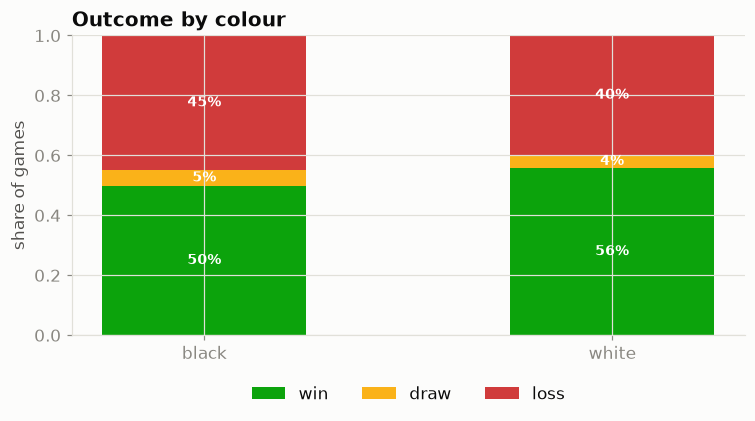

In [6]:
by_color = (
    df.groupby("my_color")["outcome"]
    .value_counts(normalize=True)
    .unstack()[["win", "draw", "loss"]]
)
display(by_color.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
bottom = np.zeros(len(by_color))
for outcome in ["win", "draw", "loss"]:
    vals = by_color[outcome].values
    ax.bar(by_color.index, vals, bottom=bottom, color=STATUS[outcome], label=outcome, width=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.03:
            ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom += vals

ax.set_title("Outcome by colour")
ax.set_ylabel("share of games")
ax.set_ylim(0, 1)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

## 6. Win rate by opening

Now we use the opening names we recovered from `ECOUrl`. Two things matter here: how *often* I reach a
given opening (frequency), and how well I *do* once I'm there (win rate). A 100% win rate over 2 games is
noise, not a pattern — so we only rank openings that show up at least 10 times.

Best-performing openings as White (>=10 games):


outcome,games,win,draw,loss
opening_family,,,,
Petrovs Defense Three Knights Game,10,0.900,0.000,0.100
Four Knights Game Scotch Variation,13,0.769,0.000,0.231
Four Knights Game,12,0.750,0.000,0.250
Closed Sicilian Defense Traditional Line,11,0.636,0.000,0.364
Kings Pawn Opening,73,0.630,0.014,0.356
Petrovs Defense Classical Variation,16,0.625,0.000,0.375
Nimzowitsch Defense,10,0.600,0.100,0.300
Scandinavian Defense Mieses Kotrc Variation,43,0.581,0.070,0.349



Best-performing openings as Black (>=10 games):


outcome,games,win,draw,loss
opening_family,,,,
Van t Kruijs Opening,20,0.700,0.000,0.300
Queens Pawn Opening Accelerated London System,13,0.692,0.000,0.308
Ruy Lopez Opening,15,0.667,0.000,0.333
Scotch Game,49,0.612,0.061,0.327
Scotch Game Classical Variation,10,0.600,0.000,0.400
Bishops Opening,20,0.600,0.100,0.300
Kings Pawn Opening Leonardis Variation,18,0.556,0.000,0.444
Four Knights Game Italian Variation,20,0.550,0.050,0.400


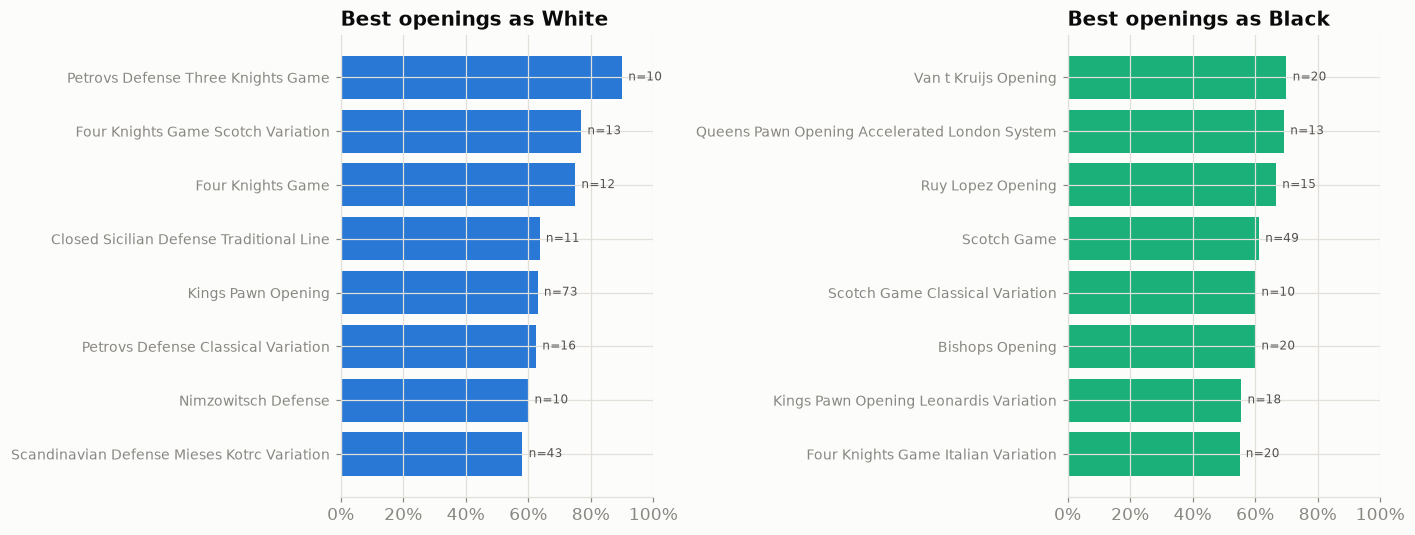

In [7]:
def opening_leaderboard(sub, min_games=10, top=10):
    grp = sub.groupby("opening_family")["outcome"].value_counts(normalize=True).unstack().fillna(0)
    grp["games"] = sub.groupby("opening_family").size()
    grp = grp[grp["games"] >= min_games]
    for col in ["win", "draw", "loss"]:
        if col not in grp.columns:
            grp[col] = 0.0
    return grp[["games", "win", "draw", "loss"]].sort_values("win", ascending=False)

white_openings = opening_leaderboard(df[df.my_color == "white"])
black_openings = opening_leaderboard(df[df.my_color == "black"])

print("Best-performing openings as White (>=10 games):")
display(white_openings.head(8).round(3))
print("\nBest-performing openings as Black (>=10 games):")
display(black_openings.head(8).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, tbl, title, color in [
    (axes[0], white_openings.head(8), "Best openings as White", CATEGORICAL[0]),
    (axes[1], black_openings.head(8), "Best openings as Black", CATEGORICAL[2]),
]:
    y = np.arange(len(tbl))
    ax.barh(y, tbl["win"], color=color)
    ax.set_yticks(y)
    ax.set_yticklabels(tbl.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    for i, (n, w) in enumerate(zip(tbl["games"], tbl["win"])):
        ax.text(w + 0.02, i, f"n={n}", va="center", fontsize=8, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

## 7. Performance by time of day and day of week

Chess.com timestamps are UTC. chefbadr's profile is registered in Yemen (UTC+3), so `datetime_local`
shifts to that offset for a "what does my week actually look like" view — if you actually play from
somewhere else, adjust the `+3` back in section 2 and rerun.

A day-of-week &times; hour-of-day heatmap answers "when do I play" (volume) and "when do I play *well*"
(win rate) in one chart. Win rate is a magnitude on a fixed 0-1 scale, so it gets the sequential blue
ramp rather than a categorical colour.

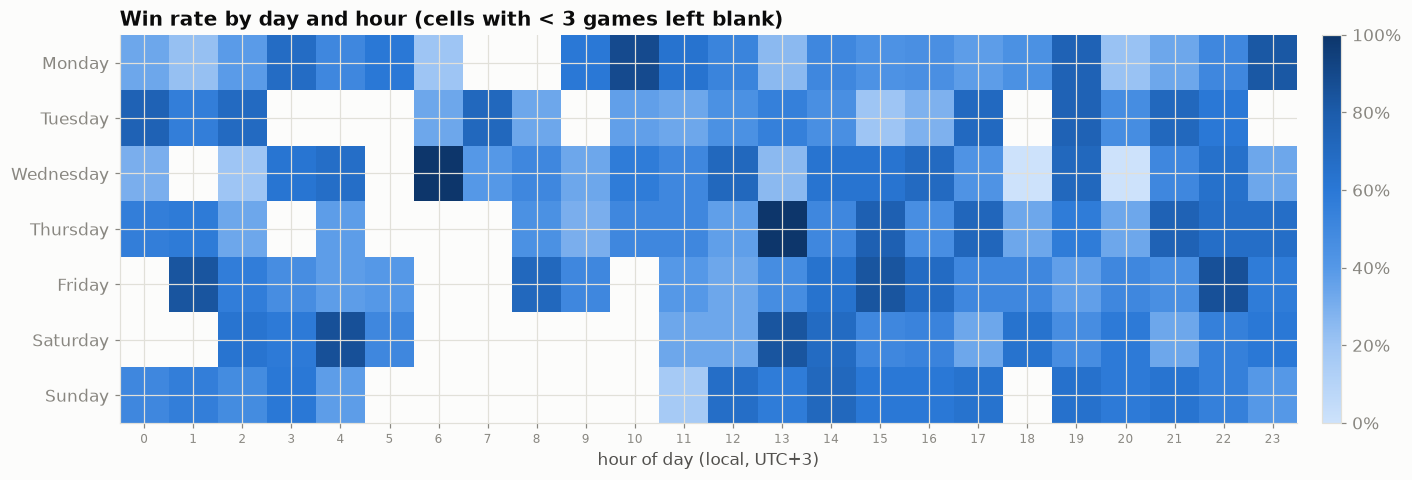

Games by day of week:


day_of_week
Monday       284
Tuesday      196
Wednesday    182
Thursday     239
Friday       205
Saturday     177
Sunday       205
Name: count, dtype: int64


Win rate by day of week:


day_of_week
Monday       0.479
Tuesday      0.531
Wednesday    0.505
Thursday     0.510
Friday       0.566
Saturday     0.582
Sunday       0.551
Name: outcome, dtype: float64

In [8]:
pivot_count = df.pivot_table(index="day_of_week", columns="hour_of_day", values="outcome",
                              aggfunc="count", observed=False).reindex(DOW_ORDER)
pivot_winrate = df.pivot_table(index="day_of_week", columns="hour_of_day",
                                values="outcome", aggfunc=lambda s: (s == "win").mean(),
                                observed=False).reindex(DOW_ORDER)

from matplotlib.colors import LinearSegmentedColormap
blue_cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

fig, ax = plt.subplots(figsize=(13, 4.5))
masked = np.ma.masked_where(pivot_count.isna() | (pivot_count < 3), pivot_winrate)
im = ax.imshow(masked, cmap=blue_cmap, aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(DOW_ORDER)))
ax.set_yticklabels(DOW_ORDER)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_xlabel("hour of day (local, UTC+3)")
ax.set_title("Win rate by day and hour (cells with < 3 games left blank)")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print("Games by day of week:")
display(df["day_of_week"].value_counts().reindex(DOW_ORDER))

dow_winrate = df.groupby("day_of_week", observed=False)["outcome"].apply(lambda s: (s == "win").mean())
print("\nWin rate by day of week:")
display(dow_winrate.round(3))

## 8. Win/loss/draw breakdown by opponent rating difference

`rating_diff = my_rating - opponent_rating`. If ratings mean anything at all, win rate should climb
steadily as this goes from negative to positive. We bucket it into ranges wide enough to have decent
sample sizes.

outcome,win,draw,loss,games
rating_diff_bucket,,,,
<-200,0.308,0.000,0.692,13
-200..-100,0.000,0.000,1.000,19
-100..-50,0.200,0.107,0.693,75
-50..0,0.227,0.049,0.724,554
0..50,0.777,0.049,0.174,546
50..100,0.783,0.043,0.174,92
100..200,0.837,0.000,0.163,43
>200,0.747,0.041,0.212,146


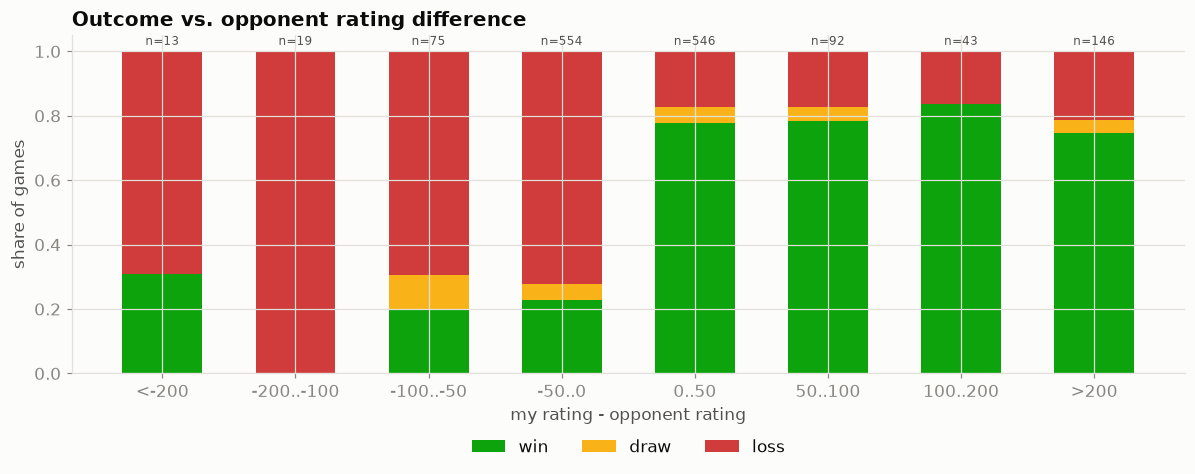

In [9]:
bins = [-10_000, -200, -100, -50, 0, 50, 100, 200, 10_000]
labels = ["<-200", "-200..-100", "-100..-50", "-50..0", "0..50", "50..100", "100..200", ">200"]
df["rating_diff_bucket"] = pd.cut(df["rating_diff"], bins=bins, labels=labels)

bucket_tbl = df.groupby("rating_diff_bucket", observed=True)["outcome"].value_counts(normalize=True).unstack().fillna(0)
bucket_tbl = bucket_tbl.reindex(columns=["win", "draw", "loss"])
bucket_tbl["games"] = df.groupby("rating_diff_bucket", observed=True).size()
display(bucket_tbl.round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(bucket_tbl))
bottom = np.zeros(len(bucket_tbl))
for outcome in ["win", "draw", "loss"]:
    vals = bucket_tbl[outcome].values
    ax.bar(x, vals, bottom=bottom, color=STATUS[outcome], label=outcome, width=0.6)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(bucket_tbl.index, rotation=0)
ax.set_xlabel("my rating - opponent rating")
ax.set_ylabel("share of games")
ax.set_title("Outcome vs. opponent rating difference")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))

for i, n in enumerate(bucket_tbl["games"]):
    ax.text(i, 1.02, f"n={n}", ha="center", fontsize=8, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

## 9. Instinct-player habits: the openings I fall into without knowing their names

I don't study openings — I play by feel. This section is about surfacing the *theory I've apparently
absorbed by osmosis* anyway: what I actually play move 1, move 2, move 3, and what those sequences are
properly called.

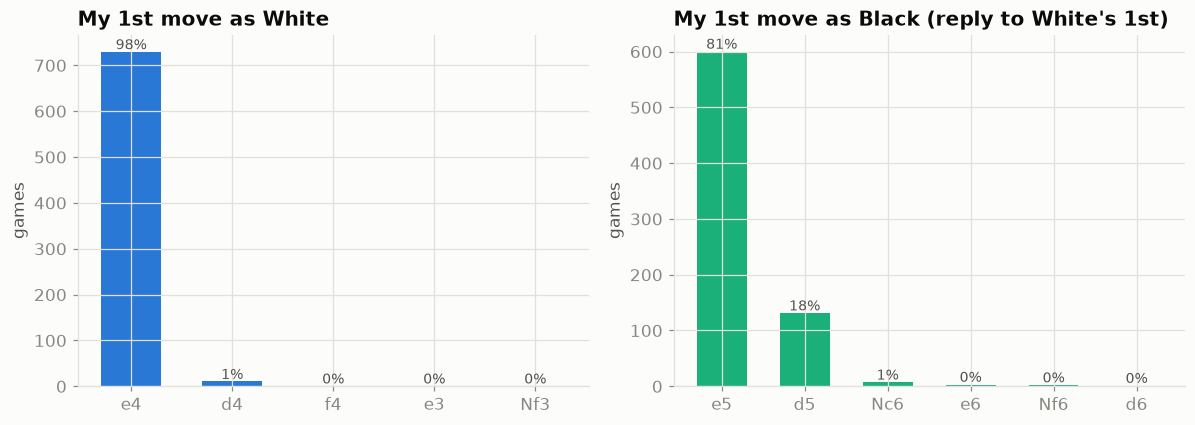

As White I play e4 in 98% of games.
As Black I reply with e5 in 81% of games.


In [10]:
white_first = df[df.my_color == "white"]["first_move_mine"].value_counts()
black_first = df[df.my_color == "black"]["first_move_mine"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title, color in [
    (axes[0], white_first, "My 1st move as White", CATEGORICAL[0]),
    (axes[1], black_first, "My 1st move as Black (reply to White's 1st)", CATEGORICAL[2]),
]:
    ax.bar(counts.index, counts.values, color=color, width=0.6)
    ax.set_title(title)
    ax.set_ylabel("games")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, f"{v/counts.sum():.0%}", ha="center", fontsize=9, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

print(f"As White I play {white_first.index[0]} in {white_first.iloc[0] / white_first.sum():.0%} of games.")
print(f"As Black I reply with {black_first.index[0]} in {black_first.iloc[0] / black_first.sum():.0%} of games.")

That's move 1. Now the *sequences* — the deepest opening line Chess.com could classify each game into,
which is effectively "how far did I follow a known book line before improvising." The most-repeated ones
are, definitionally, the openings that are actually part of my instinctive repertoire even though I
couldn't have named them beforehand.

In [11]:
def top_sequences(sub, top=10):
    tbl = sub["opening_name"].value_counts().head(top).to_frame("games")
    win_rate = sub.groupby("opening_name")["outcome"].apply(lambda s: (s == "win").mean())
    tbl["win_rate"] = tbl.index.map(win_rate).round(3)
    return tbl

white_seq = top_sequences(df[df.my_color == "white"])
black_seq = top_sequences(df[df.my_color == "black"])

print("Most-repeated exact opening sequences as White:")
display(white_seq)
print("\nMost-repeated exact opening sequences as Black:")
display(black_seq)

Most-repeated exact opening sequences as White:


,games,win_rate
opening_name,,
Kings Pawn Opening 1...e5,65,0.600
Kings Pawn Opening Kings Knight Variation,33,0.545
Philidor Defense 3.Nc3,25,0.520
Three Knights Opening 3...Bc5,23,0.435
Three Knights Opening,20,0.450
Three Knights Opening 3...Bc5 4.Nxe5 Nxe5 5.d4,20,0.750
Scandinavian Defense Mieses Kotrc Variation 3.Nc3,18,0.611
Petrovs Defense Classical Variation,15,0.600
Four Knights Game Scotch Variation Accepted 5.Nxd4,14,0.500



Most-repeated exact opening sequences as Black:


,games,win_rate
opening_name,,
Kings Pawn Opening 1...e5,62,0.419
Center Game Accepted Normal Variation,19,0.526
Kings Pawn Opening Kings Knight Variation,18,0.333
Scotch Game,18,0.556
Van t Kruijs Opening 1...e5,17,0.647
Four Knights Game Italian Variation,17,0.471
Englund Gambit,15,0.600
Scotch Game 3...exd4 4.Nxd4 Nxd4 5.Qxd4,15,0.533
Ruy Lopez Opening,15,0.667


## 10. Castling habits

How early do I castle, and which side? `castle_move_number` counts full moves (not plies) from the start
of the game to the move on which *I* castled; it's `NaN` for games where I never did.

I castle in 64% of games.
Of those, 65% kingside / 35% queenside.
Average castling move: 11.6 (median 11).


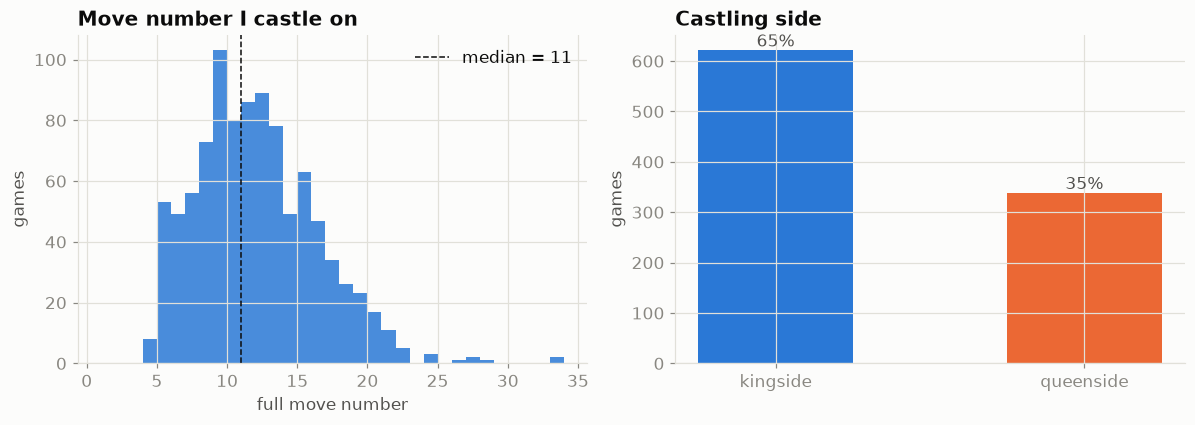


Win rate: castled vs never castled this game


outcome,draw,loss,win
castled,,,
False,0.038,0.384,0.578
True,0.054,0.445,0.501


In [12]:
castle_rate = df["castled"].mean()
side_split = df.loc[df["castled"], "castle_side"].value_counts(normalize=True)
avg_move = df["castle_move_number"].mean()
median_move = df["castle_move_number"].median()

print(f"I castle in {castle_rate:.0%} of games.")
print(f"Of those, {side_split.get('kingside', 0):.0%} kingside / {side_split.get('queenside', 0):.0%} queenside.")
print(f"Average castling move: {avg_move:.1f} (median {median_move:.0f}).")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["castle_move_number"].dropna(), bins=range(1, 35), color=CATEGORICAL[0], alpha=0.85)
axes[0].axvline(median_move, color=INK, linestyle="--", linewidth=1, label=f"median = {median_move:.0f}")
axes[0].set_title("Move number I castle on")
axes[0].set_xlabel("full move number")
axes[0].set_ylabel("games")
axes[0].legend(frameon=False)

side_counts = df.loc[df["castled"], "castle_side"].value_counts()
axes[1].bar(side_counts.index, side_counts.values, color=[CATEGORICAL[0], CATEGORICAL[1]], width=0.5)
axes[1].set_title("Castling side")
axes[1].set_ylabel("games")
for i, v in enumerate(side_counts.values):
    axes[1].text(i, v + 8, f"{v/side_counts.sum():.0%}", ha="center", color=INK_SECONDARY)

plt.tight_layout()
plt.show()

print("\nWin rate: castled vs never castled this game")
display(df.groupby("castled")["outcome"].value_counts(normalize=True).unstack().round(3))

## 11. Average game length, and how my games actually end

Game length here is in full moves (`num_full_moves`), reconstructed by replaying every game rather than
trusting any single header, since it's the same replay loop we already needed for castling and first
moves. "How it ends" comes straight out of the `classify_termination` logic from section 2.

count    1488.0
mean       31.9
std        18.5
min         2.0
25%        18.0
50%        28.0
75%        43.0
max       106.0
Name: num_full_moves, dtype: float64


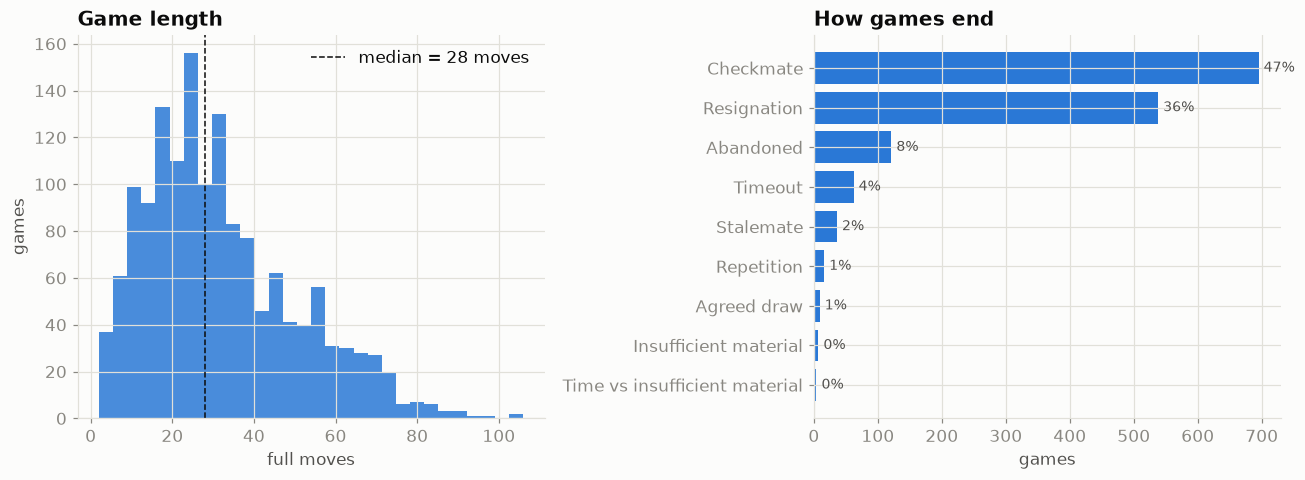

In [13]:
print(df["num_full_moves"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["num_full_moves"], bins=30, color=CATEGORICAL[0], alpha=0.85)
axes[0].axvline(df["num_full_moves"].median(), color=INK, linestyle="--", linewidth=1,
                 label=f"median = {df['num_full_moves'].median():.0f} moves")
axes[0].set_title("Game length")
axes[0].set_xlabel("full moves")
axes[0].set_ylabel("games")
axes[0].legend(frameon=False)

term_counts = df["termination_reason"].value_counts()
axes[1].barh(term_counts.index[::-1], term_counts.values[::-1], color=CATEGORICAL[0])
axes[1].set_title("How games end")
axes[1].set_xlabel("games")
for i, v in enumerate(term_counts.values[::-1]):
    axes[1].text(v + 8, i, f"{v/term_counts.sum():.0%}", va="center", fontsize=9, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

Endings only get interesting once you split them by outcome — "I win by X" and "I lose by X" are very
different stories (e.g. winning on time says something about my opponents' time management or my own
flagging technique; losing on time says something about mine).

outcome,win,draw,loss
termination_reason,,,
Abandoned,65,0,56
Agreed draw,0,9,0
Checkmate,312,0,383
Insufficient material,0,7,0
Repetition,0,16,0
Resignation,370,0,168
Stalemate,0,36,0
Time vs insufficient material,0,4,0
Timeout,39,0,23


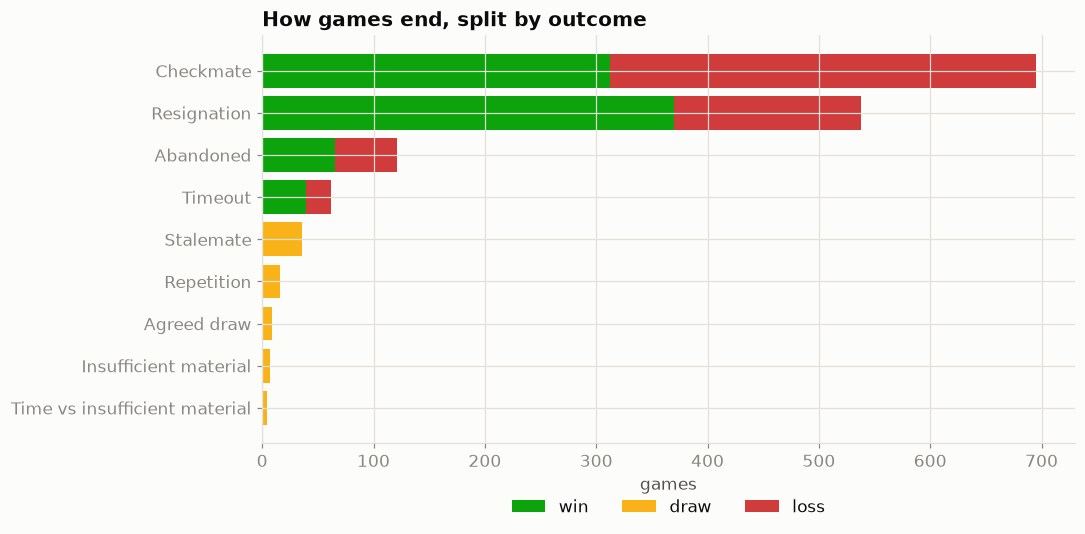

In [14]:
end_by_outcome = pd.crosstab(df["termination_reason"], df["outcome"])
end_by_outcome = end_by_outcome.reindex(columns=[c for c in ["win", "draw", "loss"] if c in end_by_outcome.columns])
display(end_by_outcome)

fig, ax = plt.subplots(figsize=(10, 5))
order = end_by_outcome.sum(axis=1).sort_values(ascending=True).index
end_by_outcome = end_by_outcome.loc[order]
left = np.zeros(len(end_by_outcome))
for outcome in ["win", "draw", "loss"]:
    if outcome not in end_by_outcome.columns:
        continue
    vals = end_by_outcome[outcome].values
    ax.barh(end_by_outcome.index, vals, left=left, color=STATUS[outcome], label=outcome)
    left += vals

ax.set_title("How games end, split by outcome")
ax.set_xlabel("games")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.show()

## 12. Which recurring patterns in my play win the most — and which lose the most

Pulling several of the engineered features together into one table: for a handful of behavioural flags
(colour, castling side, castling speed, favourite openings, time control), how much does my win rate
move away from my overall baseline? This is the closest thing to "here's what actually correlates with
me winning" that a purely descriptive, no-engine-eval notebook can offer.

Baseline win rate: 52.8%



,games,win_rate,lift_vs_baseline
pattern,,,
Rated >= opponent going in,847,0.771,0.243
Shorter-than-median game,751,0.605,0.076
Never castled,529,0.578,0.050
Playing White,744,0.558,0.030
Time control: rapid,1465,0.527,-0.001
Castled queenside,338,0.515,-0.013
Castled early (<= median move),508,0.514,-0.014
Playing Black,744,0.499,-0.030
Castled kingside,621,0.493,-0.035


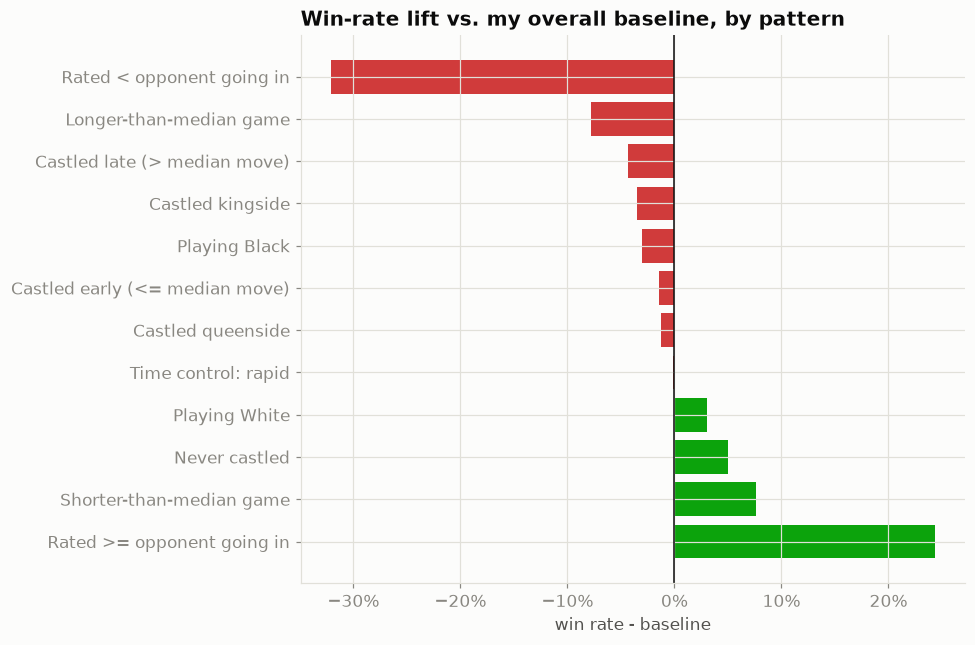

In [15]:
baseline = (df["outcome"] == "win").mean()

def win_rate_lift(mask, label, min_games=20):
    n = mask.sum()
    if n < min_games:
        return None
    wr = (df.loc[mask, "outcome"] == "win").mean()
    return {"pattern": label, "games": n, "win_rate": round(wr, 3), "lift_vs_baseline": round(wr - baseline, 3)}

patterns = [
    win_rate_lift(df.my_color == "white", "Playing White"),
    win_rate_lift(df.my_color == "black", "Playing Black"),
    win_rate_lift(df.castled & (df.castle_side == "kingside"), "Castled kingside"),
    win_rate_lift(df.castled & (df.castle_side == "queenside"), "Castled queenside"),
    win_rate_lift(df.castled & (df.castle_move_number <= df.castle_move_number.median()), "Castled early (<= median move)"),
    win_rate_lift(df.castled & (df.castle_move_number > df.castle_move_number.median()), "Castled late (> median move)"),
    win_rate_lift(~df.castled, "Never castled"),
    win_rate_lift(df.rating_diff >= 0, "Rated >= opponent going in"),
    win_rate_lift(df.rating_diff < 0, "Rated < opponent going in"),
    win_rate_lift(df.time_class == "rapid", "Time control: rapid"),
    win_rate_lift(df.num_full_moves <= df.num_full_moves.median(), "Shorter-than-median game"),
    win_rate_lift(df.num_full_moves > df.num_full_moves.median(), "Longer-than-median game"),
]
patterns = pd.DataFrame([p for p in patterns if p]).sort_values("lift_vs_baseline", ascending=False)
print(f"Baseline win rate: {baseline:.1%}\n")
display(patterns.set_index("pattern"))

fig, ax = plt.subplots(figsize=(9, 6))
colors = [STATUS["win"] if v >= 0 else STATUS["loss"] for v in patterns["lift_vs_baseline"]]
ax.barh(patterns["pattern"], patterns["lift_vs_baseline"], color=colors)
ax.axvline(0, color=INK, linewidth=1)
ax.set_title("Win-rate lift vs. my overall baseline, by pattern")
ax.set_xlabel("win rate - baseline")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 13. Headline stats

The numbers below are exactly the ones quoted in the project README — computed here so they can never
drift out of sync with the data.

In [16]:
white_best = white_openings.head(1)
black_best = black_openings.head(1)
top_white_seq = white_seq.index[0]
top_black_seq = black_seq.index[0]

headlines = {
    "total_games": len(df),
    "date_range": f"{df['datetime_utc'].min().date()} to {df['datetime_utc'].max().date()}",
    "overall_win_rate": round((df.outcome == "win").mean(), 3),
    "overall_record": dict(df["outcome"].value_counts()),
    "favourite_time_control": df["time_class"].value_counts().index[0],
    "favourite_time_control_share": round(df["time_class"].value_counts(normalize=True).iloc[0], 3),
    "peak_rapid_rating": int(df.loc[df.time_class == "rapid", "my_rating"].max()),
    "latest_rapid_rating": int(df[df.time_class == "rapid"].sort_values("datetime_utc")["my_rating"].iloc[-1]),
    "white_first_move": white_first.index[0],
    "white_first_move_share": round(white_first.iloc[0] / white_first.sum(), 3),
    "black_first_reply": black_first.index[0],
    "black_first_reply_share": round(black_first.iloc[0] / black_first.sum(), 3),
    "top_white_opening": top_white_seq,
    "top_white_opening_games": int(white_seq.loc[top_white_seq, "games"]),
    "top_black_opening": top_black_seq,
    "top_black_opening_games": int(black_seq.loc[top_black_seq, "games"]),
    "castle_rate": round(castle_rate, 3),
    "castle_kingside_share": round(side_split.get("kingside", 0), 3),
    "median_castle_move": float(median_move),
    "median_game_length_moves": float(df["num_full_moves"].median()),
    "most_common_ending": term_counts.index[0],
    "most_common_ending_share": round(term_counts.iloc[0] / term_counts.sum(), 3),
    "best_day": dow_winrate.idxmax(),
    "best_day_win_rate": round(dow_winrate.max(), 3),
    "biggest_pattern_lift": patterns.iloc[0]["pattern"],
    "biggest_pattern_lift_value": patterns.iloc[0]["lift_vs_baseline"],
}

for k, v in headlines.items():
    print(f"{k}: {v}")

with open(PROJECT_ROOT / "data" / "processed" / "headline_stats.json", "w", encoding="utf-8") as f:
    json.dump(headlines, f, indent=2, default=str)

total_games: 1488
date_range: 2022-11-24 to 2026-08-07
overall_win_rate: 0.528
overall_record: {'win': np.int64(786), 'loss': np.int64(630), 'draw': np.int64(72)}
favourite_time_control: rapid
favourite_time_control_share: 0.985
peak_rapid_rating: 1259
latest_rapid_rating: 1148
white_first_move: e4
white_first_move_share: 0.981
black_first_reply: e5
black_first_reply_share: 0.806
top_white_opening: Kings Pawn Opening 1...e5
top_white_opening_games: 65
top_black_opening: Kings Pawn Opening 1...e5
top_black_opening_games: 62
castle_rate: 0.644
castle_kingside_share: 0.648
median_castle_move: 11.0
median_game_length_moves: 28.0
most_common_ending: Checkmate
most_common_ending_share: 0.467
best_day: Saturday
best_day_win_rate: 0.582
biggest_pattern_lift: Rated >= opponent going in
biggest_pattern_lift_value: 0.243


## 14. Engine analysis (v2): where do I actually blunder?

Everything above is **outcome-based**: it tells you what correlates with winning, never whether any
individual move was actually good. A game full of shaky moves that happens to end in checkmate for me
looks identical, in sections 1-13, to a game I played cleanly start to finish. This section fixes that by
replaying real games through [Stockfish](https://stockfishchess.org/) — a free, open-source chess
engine — and scoring *move quality* directly.

**What "centipawn loss" means.** A centipawn is 1/100th of a pawn, the standard unit engines use to
score a position (being a pawn up is roughly +100). For each of my moves, `scripts/analyze_blunders.py`
asks Stockfish for the position's evaluation twice: once *before* the move (the best result Stockfish
thinks was available) and once *after* the move I actually played. The gap between those two, floored at
0, is that move's **centipawn loss** — how much of my advantage (or how much less of my disadvantage) I
gave up by not playing the engine's line. 0 means Stockfish rates my move as good as its own top choice;
300 means I let a 3-pawn edge evaporate in one move. (Forced mates get a huge constant score rather than
a real centipawn number, so the setup cell below caps evaluations at +/-1000cp before computing anything
averaged — otherwise a single move that turns a mate-for-me into a mate-for-them would swamp the mean by
itself. More on that where it comes up.)

**How moves are classified.** Following the rough convention chess.com/lichess post-game review uses:

| cp loss | label |
|---|---|
| &ge; 300 | **blunder** |
| 100-299 | **mistake** |
| 50-99 | **inaccuracy** |
| < 50 | ok |

**Game phase** (opening / middlegame / endgame) is a heuristic, not an official definition: the first 20
plies (10 full moves) count as the opening — matching this dataset's own median castling move of 11 from
section 10 — and a position counts as the endgame once queens are off or total non-pawn material left is
a rook-and-minor-piece or less. Everything in between is the middlegame. See `game_phase()` in the script
for the exact rule.

**The sample.** Full-strength engine analysis (the kind chess.com/lichess run) takes seconds per
position; over my whole 1,488-game history that's hours, just to analyse games from 2022 that say
nothing about how I play *now*. So this only covers a configurable sample — by default my **300 most
recent rapid games** (rapid being 98.5% of everything I play, per section 3) — at a **modest depth
(14 ply)**, which a local benchmark put at ~75ms/position, keeping the full run to well under an hour.
Both the sample size and depth are `--sample-size`/`--depth` flags on the script; a wider or deeper
re-run just tops up whatever games aren't analysed yet rather than starting over.

Only *my* moves get classified below (that's the point of self-analysis), though every position in a
game still gets one engine call regardless, since each score doubles as the "after" reading for the move
that reached it and the "before" reading for whoever moves next.

```bash
python scripts/setup_engine.py          # once, downloads Stockfish for Windows (~110MB, gitignored)
python scripts/analyze_blunders.py      # writes data/processed/engine_analysis.csv
```

In [17]:
engine_path = PROJECT_ROOT / "data" / "processed" / "engine_analysis.csv"
if not engine_path.exists():
    raise FileNotFoundError(
        f"{engine_path} not found -- run scripts/setup_engine.py then scripts/analyze_blunders.py first."
    )

moves = pd.read_csv(engine_path)

# Bring in per-game context (opening, url, time-of-day) from the tidy DataFrame we already built.
moves = moves.merge(
    df[["uuid", "url", "opening_family", "my_color", "time_class", "datetime_local", "hour_of_day"]],
    on="uuid", how="left",
)
moves["datetime_local"] = pd.to_datetime(moves["datetime_local"])

PHASE_ORDER = ["opening", "middlegame", "endgame"]
moves["phase"] = pd.Categorical(moves["phase"], categories=PHASE_ORDER, ordered=True)

CLASS_ORDER = ["ok", "inaccuracy", "mistake", "blunder"]
moves["classification"] = pd.Categorical(moves["classification"], categories=CLASS_ORDER, ordered=True)

# scripts/analyze_blunders.py stores raw engine scores, and treats forced mate as a huge constant
# (+/-100,000 "centipawns") so it still sorts/compares sanely against ordinary evaluations -- see
# MATE_SCORE_CP in that script. That's fine for *classifying* a move (anything past the 300cp blunder
# threshold is a blunder regardless of exact size), but it wrecks any *average*: a single move that
# swings a forced mate for me into a forced mate against me registers as a ~200,000cp swing, which would
# dominate a mean over thousands of ordinary moves. The standard fix (the same one lichess/chess.com use
# for their own average-centipawn-loss numbers) is to cap each evaluation at a sensible ceiling --
# 1000cp (10 pawns) here, well past "this position is already completely won or lost" -- *before* taking
# the difference. Classification stays on the raw (uncapped) cp_loss column; only the aggregate stats
# and "worst moves" ranking in this section use the capped version.
CP_CAP = 1000
moves["cp_before_capped"] = moves["cp_before"].clip(-CP_CAP, CP_CAP)
moves["cp_after_capped"] = moves["cp_after"].clip(-CP_CAP, CP_CAP)
moves["cp_loss_capped"] = (moves["cp_before_capped"] - moves["cp_after_capped"]).clip(lower=0)

# A one-hue ordinal ramp for move-quality severity (validated: light-end contrast >= 2:1,
# monotone lightness, single hue -- see the dataviz palette this project follows).
SEQ_SEVERITY = ["#d99568", "#dd7238", "#c94a2f", "#8f1d1d"]
SEVERITY_COLOR = dict(zip(CLASS_ORDER, SEQ_SEVERITY))

overall_blunder_rate = (moves["classification"] == "blunder").mean()
class_counts = moves["classification"].value_counts().reindex(CLASS_ORDER)

print(f"{moves['uuid'].nunique()} games analysed, {len(moves)} of my own moves scored")
print(f"sample date range: {moves['datetime_local'].min().date()} to {moves['datetime_local'].max().date()}")
print(f"\nmove-quality breakdown:")
for cls in CLASS_ORDER:
    print(f"  {cls:<11} {class_counts[cls]:>5}  ({class_counts[cls] / len(moves):.1%})")
print(f"\noverall blunder rate: {overall_blunder_rate:.1%}")
print(f"average centipawn loss per move (capped at +/-{CP_CAP}cp): {moves['cp_loss_capped'].mean():.1f}")

300 games analysed, 10216 of my own moves scored
sample date range: 2026-03-24 to 2026-08-07

move-quality breakdown:
  ok           7208  (70.6%)
  inaccuracy   1085  (10.6%)
  mistake      1210  (11.8%)
  blunder       713  (7.0%)

overall blunder rate: 7.0%
average centipawn loss per move (capped at +/-1000cp): 58.7


### 14.1 Do my favourite openings actually cost me?

"Favourite" here means *frequency*, same spirit as section 9: the opening families I actually land in
most often within this sample, not the ones with the best win rate. We only rank ones that show up at
least 6 times in the sample (lower than section 6's threshold of 10, since the engine sample is a fifth
of the full history) and compare each one's blunder rate against my overall baseline.

,games,moves,blunder_rate
opening_family,,,
Three Knights Opening,29,846,0.073
Four Knights Game Scotch Variation Accepted,12,382,0.089
Kings Pawn Opening Kings Knight Variation,11,333,0.087
Kings Pawn Opening,11,395,0.089
Scotch Game,10,366,0.063
Bishops Opening Berlin Defense,10,400,0.090
Queens Pawn Opening Zukertort Chigorin Variation,8,352,0.065
Caro Kann Defense,7,279,0.057
Philidor Defense,7,269,0.082


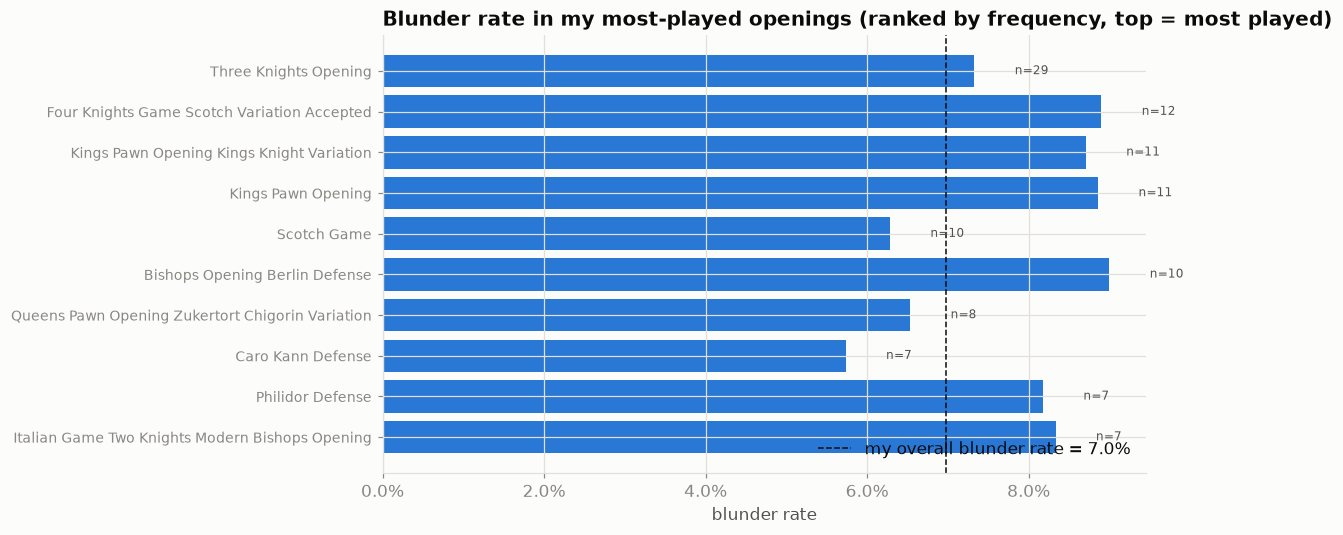

In [18]:
MIN_GAMES_OPENING = 6

sample_games = df[df["uuid"].isin(moves["uuid"])]
opening_freq = sample_games["opening_family"].value_counts()
favourite_openings = opening_freq[opening_freq >= MIN_GAMES_OPENING].index.tolist()

opening_stats = (
    moves[moves["opening_family"].isin(favourite_openings)]
    .groupby("opening_family", observed=True)
    .agg(games=("uuid", "nunique"), moves=("cp_loss", "size"), blunder_rate=("classification", lambda s: (s == "blunder").mean()))
    .reindex(favourite_openings)  # keep frequency order = "favourite" order
    .sort_values("games", ascending=False)
)
display(opening_stats.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(opening_stats))
ax.barh(y, opening_stats["blunder_rate"], color=CATEGORICAL[0])
ax.axvline(overall_blunder_rate, color=INK, linestyle="--", linewidth=1,
           label=f"my overall blunder rate = {overall_blunder_rate:.1%}")
ax.set_yticks(y)
ax.set_yticklabels(opening_stats.index, fontsize=9)
ax.invert_yaxis()  # most-played opening (favourite) on top
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("blunder rate")
ax.set_title("Blunder rate in my most-played openings (ranked by frequency, top = most played)")
ax.legend(frameon=False, loc="lower right")
for i, (n, r) in enumerate(zip(opening_stats["games"], opening_stats["blunder_rate"])):
    ax.text(r + 0.005, i, f"n={n}", va="center", fontsize=8, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

### 14.2 Average centipawn loss by game phase — where do I fall apart?

Same idea as section 11's "how do games end" but for move quality instead of outcome: average
centipawn loss is a magnitude (how much, on average, I give up per move), so it gets a single hue; the
move-quality mix alongside it uses the ordinal severity ramp from the setup cell, since "ok -> inaccuracy
-> mistake -> blunder" is an ordered scale, not an arbitrary category.

,avg_cp_loss,n_moves
phase,,
opening,42.9,3129
middlegame,77.7,3731
endgame,52.3,3356


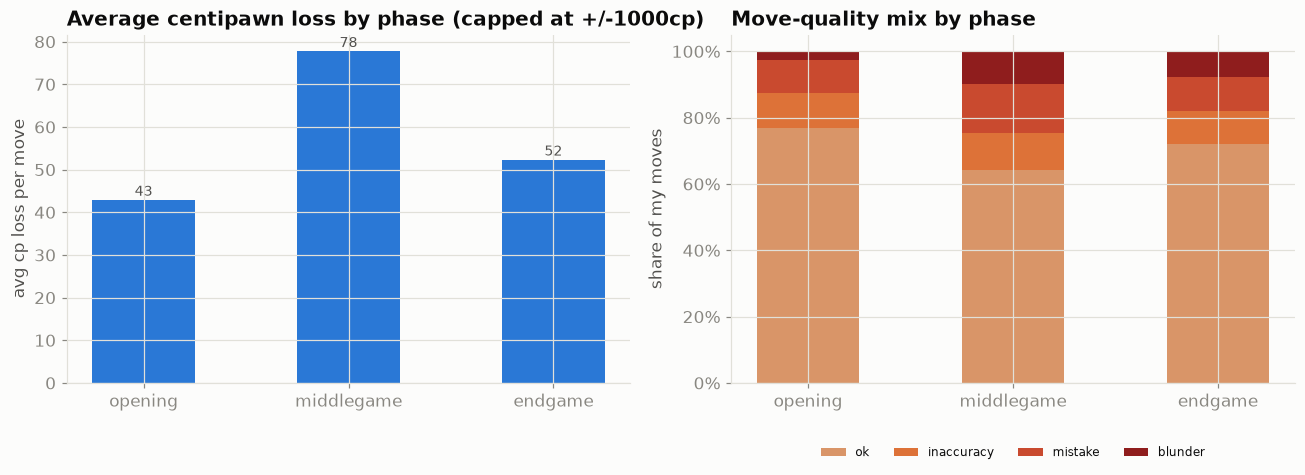

In [19]:
phase_cpl = moves.groupby("phase", observed=False)["cp_loss_capped"].mean().reindex(PHASE_ORDER)
phase_n = moves.groupby("phase", observed=False).size().reindex(PHASE_ORDER)
phase_mix = (
    moves.groupby("phase", observed=False)["classification"]
    .value_counts(normalize=True).unstack().reindex(columns=CLASS_ORDER).fillna(0).reindex(PHASE_ORDER)
)

display(phase_cpl.round(1).to_frame("avg_cp_loss").join(phase_n.to_frame("n_moves")))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(PHASE_ORDER, phase_cpl.values, color=CATEGORICAL[0], width=0.5)
axes[0].set_title(f"Average centipawn loss by phase (capped at +/-{CP_CAP}cp)")
axes[0].set_ylabel("avg cp loss per move")
for i, v in enumerate(phase_cpl.values):
    axes[0].text(i, v + 1, f"{v:.0f}", ha="center", color=INK_SECONDARY, fontsize=9)

bottom = np.zeros(len(PHASE_ORDER))
for cls in CLASS_ORDER:
    vals = phase_mix[cls].values
    axes[1].bar(PHASE_ORDER, vals, bottom=bottom, color=SEVERITY_COLOR[cls], label=cls, width=0.5)
    bottom += vals
axes[1].set_title("Move-quality mix by phase")
axes[1].set_ylabel("share of my moves")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=8)

plt.tight_layout()
plt.show()

### 14.3 Blunder rate by time of day

Same local-time convention as section 7 (UTC+3). Hours with too few of my moves in the sample to be
reliable are left blank rather than shown as a noisy 0% or 100%.

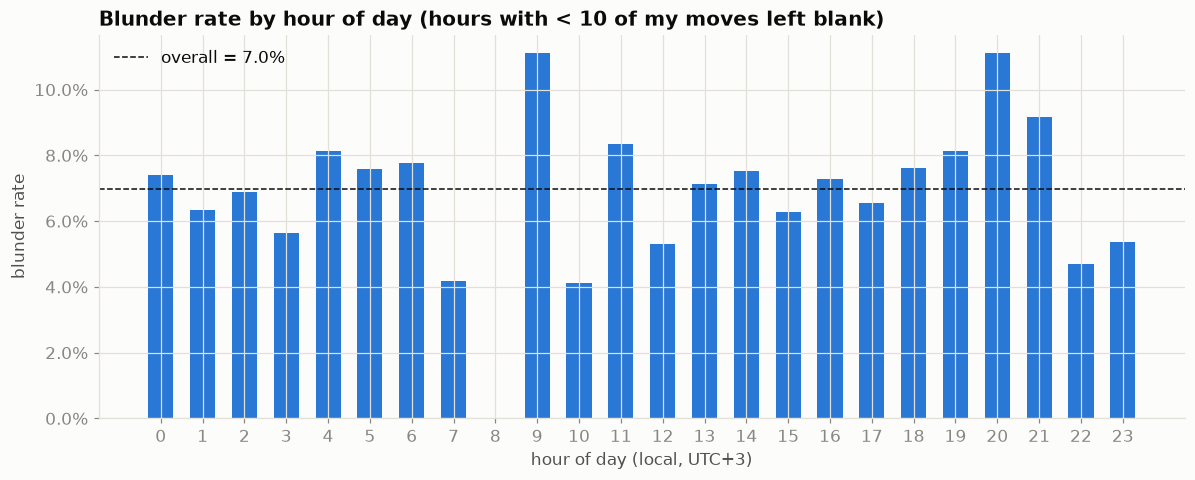

Worst hours (by blunder rate, >= 10 moves):


,n_moves,blunder_rate
hour_of_day,,
20,234,0.111
9,45,0.111
21,120,0.092
11,60,0.083
19,418,0.081


In [20]:
HOUR_MIN_MOVES = 10

hour_n = moves.groupby("hour_of_day").size()
hour_blunder_rate = moves.groupby("hour_of_day")["classification"].apply(lambda s: (s == "blunder").mean())
valid_hours = hour_n[hour_n >= HOUR_MIN_MOVES].index

x = list(range(24))
y = [hour_blunder_rate[h] if h in valid_hours else np.nan for h in x]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x, y, color=CATEGORICAL[0], width=0.6)
ax.axhline(overall_blunder_rate, color=INK, linestyle="--", linewidth=1,
           label=f"overall = {overall_blunder_rate:.1%}")
ax.set_xticks(x)
ax.set_xlabel("hour of day (local, UTC+3)")
ax.set_ylabel("blunder rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title(f"Blunder rate by hour of day (hours with < {HOUR_MIN_MOVES} of my moves left blank)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

hour_table = pd.DataFrame({"n_moves": hour_n, "blunder_rate": hour_blunder_rate}).reindex(valid_hours)
print("Worst hours (by blunder rate, >= {} moves):".format(HOUR_MIN_MOVES))
display(hour_table.sort_values("blunder_rate", ascending=False).head(5).round(3))

### 14.4 My worst moves in the sample, with links

Not "worst moves ever" — worst moves *in this 300-game sample*, since that's all Stockfish has looked
at. Ranked by the capped centipawn loss from the setup cell (raw mate-score swings would otherwise fill
this list with ties at the same nominal "worst" score and bury the more instructive ones — a queen
hanging in an ordinary position is a more useful thing to see than "turned my forced mate into theirs").

In [21]:
worst_moves = moves.sort_values("cp_loss_capped", ascending=False).head(15).reset_index(drop=True)

for i, row in worst_moves.iterrows():
    color = row["mover_color"].capitalize()
    print(f"{i + 1:>2}. cp_loss={row['cp_loss_capped']:>4.0f}  {color} played {row['move_san']!r} on move {row['move_number']} "
          f"({row['phase']}) -- {row['opening_family']}")
    print(f"     {row['datetime_local'].date()}  {row['url']}")

worst_moves[["datetime_local", "opening_family", "move_number", "mover_color", "move_san", "phase", "cp_loss_capped", "classification", "url"]]

 1. cp_loss=2000  Black played 'Rxg6' on move 51 (endgame) -- Queens Pawn Opening Zukertort Chigorin Variation
     2026-04-08  https://www.chess.com/game/live/167003692906
 2. cp_loss=2000  White played 'c8=Q' on move 24 (endgame) -- Three Knights Opening
     2026-04-16  https://www.chess.com/game/live/167367917074
 3. cp_loss=1555  Black played 'Kf8' on move 30 (endgame) -- Queens Pawn Opening Chigorin Variation
     2026-04-09  https://www.chess.com/game/live/167050158250
 4. cp_loss=1480  Black played 'b4' on move 30 (endgame) -- Scotch Game Scotch Gambit Dubois Reti Perreux Variation
     2026-08-03  https://www.chess.com/game/live/172472162702
 5. cp_loss=1411  Black played 'Qf4+' on move 18 (middlegame) -- Queens Gambit Accepted Old Variation
     2026-04-01  https://www.chess.com/game/live/166698532856
 6. cp_loss=1322  White played 'Re7' on move 23 (middlegame) -- Scotch Game
     2026-04-27  https://www.chess.com/game/live/167899951526
 7. cp_loss=1234  Black played 'Qh2+' o

,datetime_local,opening_family,move_number,mover_color,move_san,phase,cp_loss_capped,classification,url
0,2026-04-08 00:50:27+00:00,Queens Pawn Opening Zukertort Chigorin Variation,51,black,Rxg6,endgame,2000,blunder,https://www.chess.com/game/live/167003692906
1,2026-04-16 02:11:09+00:00,Three Knights Opening,24,white,c8=Q,endgame,2000,blunder,https://www.chess.com/game/live/167367917074
2,2026-04-09 02:04:39+00:00,Queens Pawn Opening Chigorin Variation,30,black,Kf8,endgame,1555,blunder,https://www.chess.com/game/live/167050158250
3,2026-08-03 17:04:11+00:00,Scotch Game Scotch Gambit Dubois Reti Perreux ...,30,black,b4,endgame,1480,blunder,https://www.chess.com/game/live/172472162702
4,2026-04-01 03:23:55+00:00,Queens Gambit Accepted Old Variation,18,black,Qf4+,middlegame,1411,blunder,https://www.chess.com/game/live/166698532856
5,2026-04-27 17:34:02+00:00,Scotch Game,23,white,Re7,middlegame,1322,blunder,https://www.chess.com/game/live/167899951526
6,2026-04-04 16:17:31+00:00,Kings Pawn Opening Leonardis Variation,26,black,Qh2+,middlegame,1234,blunder,https://www.chess.com/game/live/166851969858
7,2026-04-04 20:05:13+00:00,Giuoco Piano Game Giuoco Pianissimo Variation,28,black,Qe2,middlegame,1226,blunder,https://www.chess.com/game/live/166860917734
8,2026-04-11 06:46:00+00:00,Scandinavian Defense Mieses Kotrc Variation,16,white,Rd2,middlegame,1075,blunder,https://www.chess.com/game/live/167146750366
9,2026-05-22 05:47:26+00:00,Italian Game Two Knights Modern Bishops Opening,11,black,Qg5,middlegame,1023,blunder,https://www.chess.com/game/live/169055733966


### 14.5 Headline stats for this section

Same idea as section 13: computed live so these numbers can't drift out of sync with the data, written
to their own file (rather than merged into `headline_stats.json`) since this is a separate, smaller-sample
analysis with its own caveats.

In [22]:
riskiest = opening_stats.sort_values("blunder_rate", ascending=False).iloc[0]
safest = opening_stats.sort_values("blunder_rate", ascending=True).iloc[0]
worst_hour_row = hour_table.sort_values("blunder_rate", ascending=False).iloc[0]
best_hour_row = hour_table.sort_values("blunder_rate", ascending=True).iloc[0]
worst_move = worst_moves.iloc[0]

blunder_headlines = {
    "engine": "Stockfish 18 (Windows AVX2 build)",
    "search_depth_ply": 14,
    "sample_time_class": "rapid",
    "sample_size_games": int(moves["uuid"].nunique()),
    "sample_date_range": f"{moves['datetime_local'].min().date()} to {moves['datetime_local'].max().date()}",
    "total_moves_analyzed": int(len(moves)),
    "cp_cap": CP_CAP,
    "overall_blunder_rate": round(overall_blunder_rate, 3),
    "overall_mistake_rate": round((moves["classification"] == "mistake").mean(), 3),
    "overall_inaccuracy_rate": round((moves["classification"] == "inaccuracy").mean(), 3),
    "avg_cp_loss_opening": round(float(phase_cpl["opening"]), 1),
    "avg_cp_loss_middlegame": round(float(phase_cpl["middlegame"]), 1),
    "avg_cp_loss_endgame": round(float(phase_cpl["endgame"]), 1),
    "riskiest_favourite_opening": riskiest.name,
    "riskiest_favourite_opening_blunder_rate": round(float(riskiest["blunder_rate"]), 3),
    "riskiest_favourite_opening_games": int(riskiest["games"]),
    "safest_favourite_opening": safest.name,
    "safest_favourite_opening_blunder_rate": round(float(safest["blunder_rate"]), 3),
    "safest_favourite_opening_games": int(safest["games"]),
    "worst_hour_local": int(worst_hour_row.name),
    "worst_hour_blunder_rate": round(float(worst_hour_row["blunder_rate"]), 3),
    "best_hour_local": int(best_hour_row.name),
    "best_hour_blunder_rate": round(float(best_hour_row["blunder_rate"]), 3),
    "worst_move_cp_loss": round(float(worst_move["cp_loss_capped"]), 0),
    "worst_move_san": worst_move["move_san"],
    "worst_move_phase": str(worst_move["phase"]),
    "worst_move_date": str(worst_move["datetime_local"].date()),
    "worst_move_url": worst_move["url"],
}

for k, v in blunder_headlines.items():
    print(f"{k}: {v}")

with open(PROJECT_ROOT / "data" / "processed" / "blunder_stats.json", "w", encoding="utf-8") as f:
    json.dump(blunder_headlines, f, indent=2, default=str)

engine: Stockfish 18 (Windows AVX2 build)
search_depth_ply: 14
sample_time_class: rapid
sample_size_games: 300
sample_date_range: 2026-03-24 to 2026-08-07
total_moves_analyzed: 10216
cp_cap: 1000
overall_blunder_rate: 0.07
overall_mistake_rate: 0.118
overall_inaccuracy_rate: 0.106
avg_cp_loss_opening: 42.9
avg_cp_loss_middlegame: 77.7
avg_cp_loss_endgame: 52.3
riskiest_favourite_opening: Bishops Opening Berlin Defense
riskiest_favourite_opening_blunder_rate: 0.09
riskiest_favourite_opening_games: 10
safest_favourite_opening: Caro Kann Defense
safest_favourite_opening_blunder_rate: 0.057
safest_favourite_opening_games: 7
worst_hour_local: 20
worst_hour_blunder_rate: 0.111
best_hour_local: 8
best_hour_blunder_rate: 0.0
worst_move_cp_loss: 2000.0
worst_move_san: Rxg6
worst_move_phase: endgame
worst_move_date: 2026-04-08
worst_move_url: https://www.chess.com/game/live/167003692906


## Closing notes

A few honest caveats for anyone re-running this:

- **Small samples get noisy fast.** Bullet and blitz have only a handful of games each — treat those
  rating lines as anecdotal, not trend.
- **"Opening name" is Chess.com's classifier, not mine.** It's doing exactly the job I want (turning
  moves I play by feel into their real names), but it occasionally tags very short games as
  "Unclassified" when a game ends before it matches a known line.
- **Local time-of-day assumes UTC+3 year-round.** Chess.com doesn't record daylight-saving/travel, so
  this is an approximation, not a guarantee.
- **Section 14's engine analysis only covers a 300-game recent sample, not full history**, and runs at a
  modest depth (14 ply) rather than the deeper search chess.com/lichess use for their own post-game
  review — a deliberate speed/precision tradeoff (see that section for the timing math). Treat cp-loss
  numbers as directionally right, not lab-grade precise; a deeper `--depth` re-run would sharpen them.
- **Opening/middlegame/endgame is a heuristic, not a rule.** The ply-count and material thresholds in
  `game_phase()` are a reasonable proxy, not an official definition — some genuinely unusual games (very
  early piece trades, long opposite-side-castling battles) will get misclassified at the boundary.

Possible follow-ups: compare performance against specific repeat opponents; look at rating gained/lost
per game (a proper Elo-delta curve) instead of raw rating snapshots; widen the engine sample past rapid
into blitz once there's enough blitz history to be worth it; check whether blunders cluster near time
pressure using the PGN's `%clk` annotations, which aren't used anywhere in this notebook yet.